# 📊 Notebook 01 — EDA & Data Preparation
## Bagian 0: Eksplorasi Data Awal & Persiapan Dataset

**Dataset:** 8.099 ulasan CoretTax/M-Pajak dari Google Play Store

**Tujuan:**
1. Loading dan inspeksi data
2. Normalisasi ringan
3. Feature engineering sederhana
4. Visualisasi distribusi & tren

## Setup & Imports

In [1]:
import sys
import os

# Tambahkan root project ke path
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import module proyek
from src.preprocessing import load_raw_data, normalize_text_basic, add_engineered_features, prepare_dataset
from src.evaluator import plot_rating_distribution, plot_monthly_trend, plot_wordcloud

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_colwidth', 100)

## 0.1 — Loading & Eksplorasi Dasar

In [2]:
# Load raw data
df_raw = load_raw_data('../data/raw/coretax_reviews.csv')
print(f"\n📊 Dataset Shape: {df_raw.shape}")
print(f"\n📋 Kolom: {list(df_raw.columns)}")
print(f"\n📅 Rentang tanggal: {df_raw['date'].min()} — {df_raw['date'].max()}")


📊 Dataset Shape: (8099, 6)

📋 Kolom: ['user_name', 'rating', 'date', 'review_text', 'likes', 'app_version']

📅 Rentang tanggal: 2021-06-04 18:42:28 — 2026-05-03 10:24:58


In [3]:
# Distribusi rating
print("\n📊 Distribusi Rating:")
print(df_raw['rating'].value_counts().sort_index())


📊 Distribusi Rating:
rating
1    6132
2     330
3     203
4     153
5    1281
Name: count, dtype: int64


In [4]:
# Duplikat teks (untuk informasi, TIDAK dihapus)
n_dup = df_raw['review_text'].duplicated().sum()
print(f"\n📊 Review duplikat: {n_dup} ({n_dup/len(df_raw)*100:.1f}%)")
print("   ℹ️  Duplikat DIPERTAHANKAN untuk menjaga volume keluhan asli")


📊 Review duplikat: 763 (9.4%)
   ℹ️  Duplikat DIPERTAHANKAN untuk menjaga volume keluhan asli


In [5]:
# Missing values
print("\n📊 Missing Values:")
print(df_raw.isnull().sum())


📊 Missing Values:
user_name      0
rating         0
date           0
review_text    0
likes          0
app_version    0
dtype: int64


In [6]:
# Sample review per rating
for r in [1, 3, 5]:
    sample = df_raw[df_raw['rating'] == r]['review_text'].head(3)
    print(f"\n⭐ Rating {r} — Contoh:")
    for text in sample:
        print(f"   • {str(text)[:100]}")


⭐ Rating 1 — Contoh:
   • ini menurut beyond BNI. adalah aplikasi pishing. hati hati.
   • sebenarnya apk ini ada maafnya gak?apk pemerintah kenapa seperti ini buang buang uang tapi tidak ber
   • Tiba2 gak bisa login. Lewat "lupa kata sandi" juga tetap gabisa walaupun pakai nomor HP dan email ya

⭐ Rating 3 — Contoh:
   • seharusnya dengan app ini, proses pelaporan jadi lebih mudah. Sangat disayangkan, belum bisa diopera
   • gk pernah bisa masuk setelah log in, layar blank putih, dan saran untuk informasi pengikinian data d
   • kami setiap thn sllu aktik bayar pajak

⭐ Rating 5 — Contoh:
   • terbantu dengan pelayanan ini terimakasih 🙏
   • apk sampah ga bisa di gunakan
   • good


## 0.2 — Normalisasi Ringan & Feature Engineering

In [7]:
# Jalankan pipeline persiapan data lengkap
df = prepare_dataset(
    filepath='../data/raw/coretax_reviews.csv',
    output_path='../data/processed/reviews_prepared.csv'
)

📦 Bagian 0 — Data Processing (Persiapan Data)

🔄 Step 1: Loading data...
   ✅ Loaded 8099 baris
   📊 Distribusi rating:
      ⭐ 1: 6132 (75.7%)
      ⭐ 2: 330 (4.1%)
      ⭐ 3: 203 (2.5%)
      ⭐ 4: 153 (1.9%)
      ⭐ 5: 1281 (15.8%)

🔄 Step 2: Normalisasi ringan...
   ✅ Normalisasi teks dasar selesai

🔄 Step 3: Feature engineering...
   ✅ Fitur ditambahkan: word_count, char_count, year_month, is_duplicate
   📊 Duplikat teks: 938 baris (11.6%)

💾 Dataset tersimpan: ../data/processed/reviews_prepared.csv
   Total baris: 8099


In [8]:
# Preview hasil
print("\n📋 Preview Dataset Setelah Persiapan:")
print(df[['rating', 'review_text', 'word_count', 'char_count', 'year_month', 'is_duplicate']].head(5))


📋 Preview Dataset Setelah Persiapan:
   rating  \
0       1   
1       1   
2       1   
3       1   
4       1   

                                                                                           review_text  \
0                                          ini menurut beyond BNI. adalah aplikasi pishing. hati hati.   
1  sebenarnya apk ini ada maafnya gak?apk pemerintah kenapa seperti ini buang buang uang tapi tidak...   
2  Tiba2 gak bisa login. Lewat "lupa kata sandi" juga tetap gabisa walaupun pakai nomor HP dan emai...   
3  kasih susah sja orang buat login sdkt" login buat apa download apknya malah susah buat login sdh...   
4                                                                                  Semua dibikin susah   

   word_count  char_count year_month  is_duplicate  
0           9          59    2026-05         False  
1          16         104    2026-05         False  
2          20         120    2026-05         False  
3          29         170    2026-

In [9]:
# Statistik panjang teks
print("\n📊 Statistik Panjang Teks:")
print(df['word_count'].describe())
print(f"\n   Review pendek (≤ 2 kata): {(df['word_count'] <= 2).sum()} "
      f"({(df['word_count'] <= 2).sum()/len(df)*100:.1f}%)")


📊 Statistik Panjang Teks:
count    8099.000000
mean       13.001976
std        13.218606
min         1.000000
25%         3.000000
50%         9.000000
75%        18.000000
max        92.000000
Name: word_count, dtype: float64

   Review pendek (≤ 2 kata): 1526 (18.8%)


## 0.3 — Visualisasi Distribusi & Tren

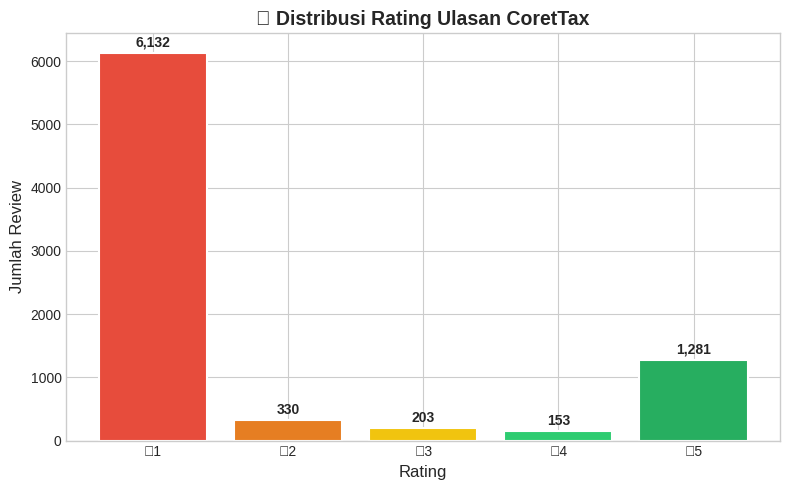

In [10]:
# 1. Distribusi Rating
plot_rating_distribution(df, save_path='results/figures/eda/rating_distribution.png')

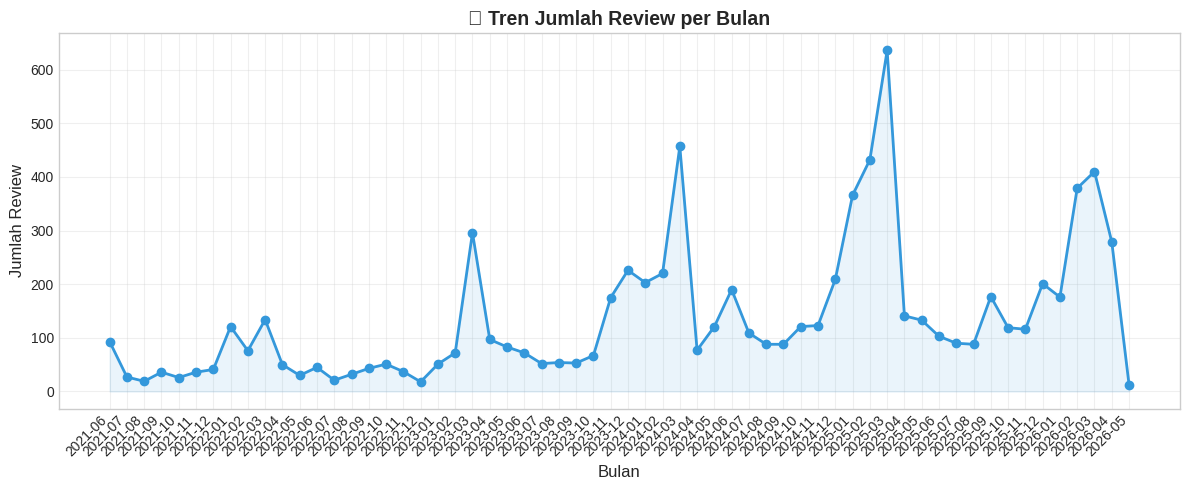

In [11]:
# 2. Tren Bulanan
plot_monthly_trend(df, save_path='results/figures/eda/monthly_trend.png')

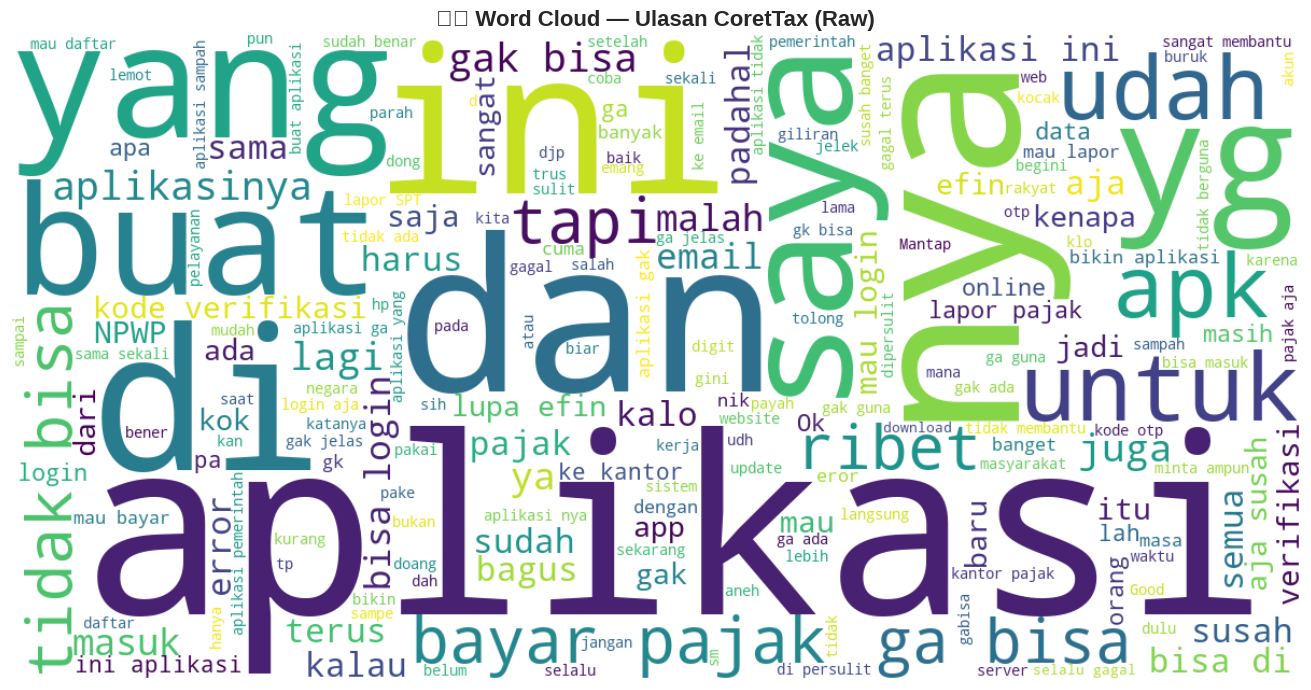

In [12]:
# 3. Word Cloud
plot_wordcloud(
    df['review_text'].tolist(),
    title='☁️ Word Cloud — Ulasan CoretTax (Raw)',
    save_path='results/figures/eda/wordcloud_raw.png'
)

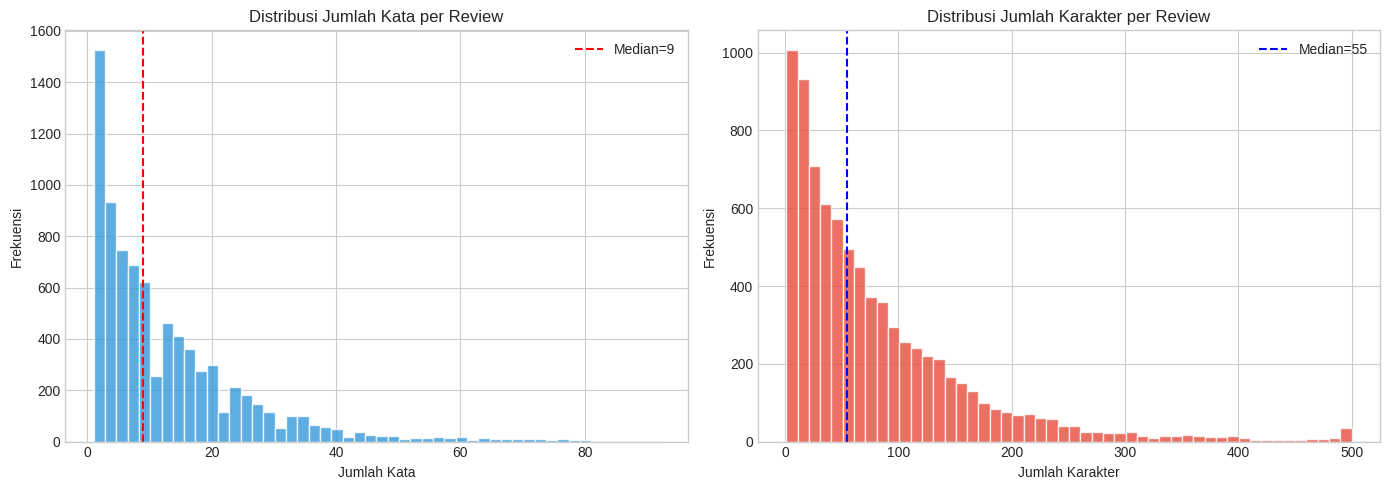

In [13]:
# 4. Distribusi panjang teks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['word_count'], bins=50, color='#3498DB', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Jumlah Kata per Review')
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--', label=f"Median={df['word_count'].median():.0f}")
axes[0].legend()

axes[1].hist(df['char_count'], bins=50, color='#E74C3C', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Jumlah Karakter')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Jumlah Karakter per Review')
axes[1].axvline(df['char_count'].median(), color='blue', linestyle='--', label=f"Median={df['char_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('results/figures/eda/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Ringkasan Bagian 0

| Metrik | Nilai |
|--------|-------|
| Total baris | 8.099 (duplikat dipertahankan) |
| Missing values | Hanya `app_version` (diisi 'unknown') |
| Kualitas teks | Sangat informal, banyak singkatan & typo |
| Dominasi | Rating 1 (~75.7%) |
| Output | `data/processed/reviews_prepared.csv` |

In [14]:
print("\n✅ Bagian 0 selesai! Dataset siap untuk tahap Labeling & Preprocessing.")


✅ Bagian 0 selesai! Dataset siap untuk tahap Labeling & Preprocessing.
